# Low Rank Matrix Factorization

```{figure} /images/dim_reduction/Netflix_Screenshot.png
---
height: 300px
name: netflix
align: center
---
Low rank matrix factorization can be used for recommender systems like Netflix
```
Netflix gained its big popularity back in the days because it focused on its recommender system strength. They personalized content discovery, ensuring users stayed engaged by always having something new to watch. The task of _recommendation_ is unsupervised, we don't know the ground truth recommendations, as opposed to supervised tasks, where we have a label or target variable.  All we have are past user ratings, from which we try to derive common patterns that allow us to provide recommendations.    

Let's go through an example to get a clearer understanding of the recommender task. Imagine we represent all users and movies in a matrix, where each entry corresponds to a user’s rating for a movie. Then we get a massive, sparse matrix (since most users have only rated a small fraction of available movies). The challenge is to predict the missing ratings so that Netflix can suggest movies that a user is likely to enjoy. For example, the user-movie matrix could look like that:
<style>
.custom-table-container th {
    writing-mode: vertical-lr;
    vertical-align: bottom;
    width: 20%;
}
</style>


<div class="custom-table-container">
    
| User|Star Wars | Interstellar | Blade Runner | Tron | 2001: Space O. | Mars Attacks | Dune | Matrix | Robo Cop | Aliens | Terminator | Solaris | Avatar | 12 Monkeys |
|----|----------|--------------|--------------|------|----------------|--------------|------|--------|----------|--------|------------|---------|--------|-----------| 
| Grace | 🤩 | 🤩 || 🙈 ||| 🤩 || 🤩 | 🤩 | 🤩 || 🤩 ||
| Carol || 🤩 | 🤩 | 🤩 |||| 🤩 |||| 🤩 || 🤩 |
| Alice | 🤩 | 🤩 | 🤩 | 🤩 | 🤩 ||||||| 🤩 | 🙈 ||
| Bob   | 🤩 ||||| 🤩 || 🤩 | 🤩| 🤩 | 🤩|| 🤩||
| Eve   | 🤩 |||| 🙈 | 🤩 || 🤩 | 🤩 |||| 🤩 ||
| Chuck | 🤩 |🤩|| 🤩| 🤩 | 🤩 | 🤩 | 🤩 || 🤩 | 🤩 || 🙈 |🤩 |
    
</div>

We have six users and 14 movies, that are rated either as _I like it_ (🤩) or _not for me_ (🙈). If no emoji is indicated, then the corresponding user has not seen the movie yet. This example matrix of user-movie preferences can be summarized by two latent (hidden) factors, the preference for cerebral science fiction and the preference for action science fiction. Carol, Alice and Chuck like cerebral science fiction. Each of the movies _Star Wars, Interstellar, Blade Runner, Tron, 2001: Space Odyssey, Matrix, Solaris,_ and _12 Monkeys_ is liked at least by two of the three users. Hence, we might consider to recommend people in that group a movie from this set that the person has not watched yet. For example, we could recommend to Carol to watch _2001: Space Odyssey_.
Likewise, we identify the more action oriented sci-fi group of Grace, Bob, Eve and Chuck, where _Star Wars, Mars Attacks, Matrix, Robo Cop, Aliens, Terminator_, and _Avatar_ score high.       

The example illustrates the idea of recommender systems to predict missing values based on the latent factors in the data. Those latent factors are here represented by a set of users that like a similar set of movies. Let's explore how we can express this intuition mathematically. Below you see the abstract representation of the groups of users and movies as a matrix. The first group of users (Carol, Alice and Chuck) and their corresponding set of (largely) liked movies is visualized in blue, and the second set of users (Grace, Bob, Eve and Chuck) and their set of movies are visualized in red.

In [1]:
def plot_matrix(matrix, ax, vmin=0, vmax=3,  grid=True): 
    ax.imshow(matrix,cmap=cmap, vmin=vmin, vmax=vmax)
    # Add grid lines for x-axis
    #plt.xticks(np.arange(-0.5, matrix.shape[1], 1), [])
    ax.set_xticks(np.arange(-0.5, matrix.shape[1], 1), [])
    ax.set_yticks(np.arange(-0.5, matrix.shape[0], 1), [])
    if grid:
        ax.grid(axis='x', color='lightgray', linewidth=3)

        # Add grid lines for y-axis
        #plt.yticks(np.arange(-0.5, matrix.shape[0], 1), [])
        ax.grid(axis='y', color='lightgray', linewidth=3)
    # Remove frame axis lines
    #ax = plt.gca()
    ax.tick_params(bottom=False, top=False, left=False, right=False)
    # Remove frame axis lines
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

::::{grid}
:gutter: 1
:class-container: sd-d-flex-row, sd-align-major-center

:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
   |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=blue, opacity=0.5]|\& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\\
 |[fill=blue, opacity=0.5]|\& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\\
 |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=magenta, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=blue, opacity=0.5]|\&|[fill=magenta, opacity=0.5]| \&|[fill=blue, opacity=0.5]|\\
};

\node[fit=(D-6-1),inner sep=0pt, fill=blue, opacity=0.5] {};
\node[fit=(D-6-8),inner sep=0pt, fill=blue, opacity=0.5] {};
\end{tikzpicture}
```
:::


::::


The matrix above reflects the positive movie indications (🤩) by the nonzero cells, that are the ones that are colored. The last row reflects Chuck, who adheres to both movie patterns, that overlap in the movies _Star Wars_ and _Matrix_. Hence, we see two cells in the last row with overlapping colors. The user-movie matrix can be decomposed into the sum of two matrices, where each matrix reflects one user-movie group.

::::{grid}
:gutter: 0
:class-container: sd-d-flex-row, sd-align-major-center

:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
   |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=blue, opacity=0.5]|\& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\\
 |[fill=blue, opacity=0.5]|\& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\\
 |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=blue, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\&|[fill=blue, opacity=0.5]|\& |[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]|\&|[fill=orange, opacity=0.05]| \&|[fill=blue, opacity=0.5]|\\
};
\end{tikzpicture}
```
:::

:::{grid-item}
:child-align: center
:columns: auto
$+$
:::

:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
   |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\\
 |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]| \&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\\
 |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
 |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
};

\end{tikzpicture}
```
:::

::::


::::{grid}
:gutter: 0
:class-container: sd-d-flex-row, sd-align-major-center


:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
   |[fill=orange, opacity=0.05]|\\
 |[fill=blue, opacity=0.5]|\\
 |[fill=blue, opacity=0.5]|\\
 |[fill=orange, opacity=0.05]|\\
 |[fill=orange, opacity=0.05]|\\
 |[fill=blue, opacity=0.5]|\\
};
\end{tikzpicture}
```
:::
:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
 |[fill=blue, opacity=0.5]|\& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\\
};
\end{tikzpicture}
```
:::

:::{grid-item}
:child-align: center
:columns: auto
$+$
:::

:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
   |[fill=magenta, opacity=0.5]|\\
 |[fill=orange, opacity=0.05]|\\
 |[fill=orange, opacity=0.05]|\\
 |[fill=magenta, opacity=0.5]|\\
 |[fill=magenta, opacity=0.5]|\\
 |[fill=magenta, opacity=0.5]|\\
};

\end{tikzpicture}
```
:::

:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
   |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
};
\end{tikzpicture}
```
:::

::::


Furthermore, each of the single user-group matrices can be represented by an outer product of a user- and a movie-vector. The sum of outer product matrices can be efficiently represented by a matrix product.

::::{grid}
:gutter: 0
:class-container: sd-d-flex-row, sd-align-major-center


:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
   |[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\\
 |[fill=blue, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\\
 |[fill=blue, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\\
 |[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\\
 |[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\\
 |[fill=blue, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\\
};
\end{tikzpicture}
```
:::
:::{grid-item}
:child-align: center
:columns: auto
```{tikz}
\begin{tikzpicture}[baseline=-0.5ex,
    style1/.style 2 args={
  matrix of math nodes,
  every node/.append style={minimum width=#2,minimum height=#1,inner sep=0,align=center},
  nodes in empty cells,
  left delimiter=(,
  right delimiter=),ampersand replacement=\&}
  ]
   \matrix [style1={5mm}{5mm}] (D) {
 |[fill=blue, opacity=0.5]|\& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\& |[fill=orange, opacity=0.05]|\& |[fill=blue, opacity=0.5]| \& |[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=blue, opacity=0.5]|\\
 |[fill=magenta, opacity=0.5]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=magenta, opacity=0.5]|\& |[fill=orange, opacity=0.05]|\&|[fill=magenta, opacity=0.5]| \&|[fill=orange, opacity=0.05]|\\
};
\end{tikzpicture}
```
:::

::::


The original $6\times 14$ matrix is now compressed into the product of a $6\times 2$-matrix and a $2\times 14$ matrix. While the original matrix contains $6\cdot 14 = 84$ elements, the low-dimensional product needs only $2\cdot 6 + 2\cdot 14 = 40$ elememts to be stored. 

The example illustrates the rough idea of recommender systems: use reoccurences in the data to compress the data, and to use the compressed data representation to make recommendations.
`````{admonition} Goal (Recommender Systems)
:class: seealso
**Given** partially observed data, represented by a data matrix $D\in\mathbb{R}^{n\times d}$.

**Find** representation that captures the dominant patterns in the data and use it to predict missing values.
`````

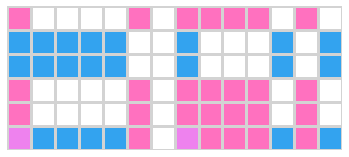

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

jupyter_blue = (0+0.2, 113/255+0.2, 188/255+0.2)
jupyter_orange = (min(242/255+0.2,1), 115/255+0.2, 33/255+0.2)
jupyter_magenta = (min(232/255+0.2,1), 62/255+0.2, 140/255+0.2)


# Define the colors for the colormap
colors = ['white', jupyter_blue, jupyter_magenta, "violet"]

# Define the values corresponding to each color
values = [0, 1, 2, 3]

# Create the custom colormap
cmap = ListedColormap(colors)
P_1 = np.array([0,1,1,0,0,1])
P1_ = np.array([1,1,1,1,1,0,0,1,0,0,0,1,0,1])
P_2 = np.array([1,0,0,1,1,1])
P2_ = np.array([1,0,0,0,0,1,0,1,1,1,1,0,1,0])
P1 = np.outer(P_1,P1_)
P2 = 2*np.outer(P_2,P2_)
ax = plt.gca()
plot_matrix(P1+P2,ax)
plt.show()

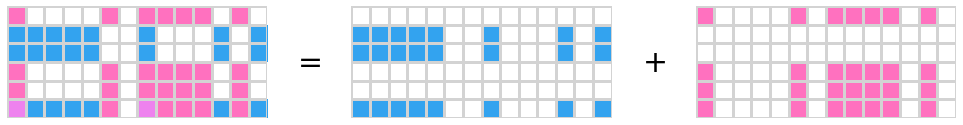

In [3]:
fig,axs = plt.subplots(1,5, figsize = (17,8), gridspec_kw = {"width_ratios": [P1.shape[1], 1, P1.shape[1],1, P1.shape[1]]})
plot_matrix(P1+P2, axs[0])
# =
plot_matrix(np.zeros((P1.shape[0],1)), axs[1], grid=False)
axs[1].text(-0.6,3, '=', fontsize=30)

plot_matrix(P1, axs[2])
# +
plot_matrix(np.zeros((P1.shape[0],1)), axs[3], grid=False)
axs[3].text(-0.6,3, '+', fontsize=30)

plot_matrix(P2, axs[4])

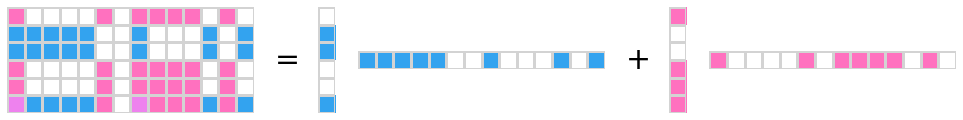

In [4]:
fig,axs = plt.subplots(1,7, figsize = (17,8), gridspec_kw = {"width_ratios": [P1.shape[1], 1, 1, P1.shape[1],1, 1,P1.shape[1]]})
plot_matrix(P1+P2, axs[0])
plot_matrix(np.zeros((P1.shape[0],1)), axs[1], grid=False)
axs[1].text(-0.6,3, '=', fontsize=30)

plot_matrix(np.reshape(P_1, (P_1.shape[0], 1)), axs[2])
plot_matrix(np.reshape(P1_, (1, P1_.shape[0])), axs[3])
plot_matrix(np.zeros((P1.shape[0],1)), axs[4], grid=False)
axs[4].text(-0.6,3, '+', fontsize=30)
plot_matrix(2*np.reshape(P_2, (P_2.shape[0], 1)), axs[5])
plot_matrix(2*np.reshape(P2_, (1, P2_.shape[0])), axs[6])

## Finding Patterns in Data via Low-Rank Matrix Factorization
Before discussing how to fill in missing values and thereby making recommendations, we discuss first how to find patterns in a fully observed dataset. Compressing the data via outer product matrices is formalized over the rank-r matrix factorization task. The example above decomposes the data into two outer products, corresponding to two user-movie patterns. More generally, we can approximate a matrix as the sum of $r$ outer products,
$$D\approx \sum_{s=1}^r Y_{\cdot s}X_{\cdot s}^\top = YX^\top$$
represented by the product of matrices $Y\in\mathbb{R}^{n\times r}$ and $X\in\mathbb{R}^{d\times r}$. We say the approximating matrix 
$$M=YX^\top$$ 
has **rank** $r$, because $r$ outer products are needed to decompose it. 
The matrix $M$ compresses the data $D$ with a **low-rank product**, by identifying $r$ (where $r$ should be much smaller than $n$ and $d$) row- and column-patterns that allow us to reconstruct the data.
`````{admonition} Task (Rank-r Matrix Factorization)
:class: tip
**Given** a data matrix $D\in\mathbb{R}^{n\times d}$ and a rank $r<\min\{n,d\}$.        
    
**Find** matrices $X\in \mathbb{R}^{d\times r}$ and $Y\in\mathbb{R}^{n\times r}$ whose product approximates the data matrix:
\begin{align}
    \min_{X,Y}&\lVert D- YX^\top\rVert^2 & \text{s.t. } X\in \mathbb{R}^{d\times r}, Y\in\mathbb{R}^{n\times r}
\end{align}
**Return** the low-rank approximation of the data $(X,Y)$.  
`````
The objective seems to be not too difficult to optimize. The squared Frobenius norm is smooth and optimizing subject to the two factor matrices doesn't seem overly complex. It's a residual sum of squares objective, similar to the one we know from regression. In regression, the residuals were computed between predicted target and given target. Here, the residuals are computed between the approximated data entry and the given one. However, unlike in regression, the matrix factorization RSS is nonconvex. The proof follows from the fact that the set of global minimizers is not a convex set.
````{prf:theorem}
The rank-$r$ matrix factorization problem, defined for a matrix $D\in\mathbb{R}^{n\times d}\neq\mathbf{0}$ and a rank $1\leq r<\min\{n,d\}$ as           
\begin{align*}
    \min_{X,Y}\ & RSS(X,Y)=\lVert D- YX^\top\rVert^2 & \text{s.t. } X\in \mathbb{R}^{d\times r}, Y\in\mathbb{R}^{n\times r}
\end{align*}
is a **nonconvex optimization problem**.
````
````{toggle}
```{prf:proof}
We show that the $RSS(X,Y)$ is not a convex function. Therefore we assume first that the $RSS(X,Y)$ is a convex function and show then that this assumption leads to a contradiction. Let $X_1,X_2\in\mathbb{R}^{d\times r}$ and $Y_1,Y_2\in\mathbb{R}^{n\times r}$, and define $\mathbf{z}_1= (X_1,Y_1)$ and $\mathbf{z}_2=(X_2,Y_2)$. Assuming that the $RSS(X,Y)$ is a convex function means that the following inequality has to hold for all $\alpha\in[0,1]$:
\begin{align*}
        RSS(\alpha \mathbf{z}_1+ (1-\alpha)\mathbf{z}_2) \leq \alpha RSS(\mathbf{z}_1) + (1-\alpha)RSS(\mathbf{z}_2).
\end{align*}
Let $\mathbf{z}^* = (X^*,Y^*)$ be a global minimizer of the rank-$r$ MF problem. Then, $\mathbf{z}^*\neq 0$ because $D\neq 0$. In addition, $\mathbf{z}_\gamma = (\gamma X^*, \frac{1}{\gamma} Y^*)$ is also a global minimizer for $\gamma\neq 0$, because the RSS attains the same global minimum function value for $\mathbf{z}_\gamma$ as for $\mathbf{z}^*$, because $\frac{1}{\gamma} Y^*(\gamma {X^*}^\top)=Y^*{X^*}^\top$. If we assume that $RSS(X,Y)$ is convex, then we have
:::{math}
:label: eq:RSS_convex
\begin{align*}
RSS(\alpha\mathbf{z}^* +(1-\alpha)\mathbf{z_\gamma}) \leq \alpha RSS(\mathbf{z}^*) + (1-\alpha) \underbrace{RSS(\mathbf{z}_\gamma}_{=RSS(\mathbf{z}^*)}) = RSS(\mathbf{z}^*)
\end{align*}
:::
However, for $\alpha=1/2$ the convex combination attains a function value of
\begin{align*}
    RSS(\alpha \mathbf{z}^* + (1-\alpha) \mathbf{z}_\gamma) &=RSS(\tfrac12 \mathbf{z}^* + \tfrac12\mathbf{z}_\gamma)\\
    &= RSS\left(\tfrac12(1+\gamma) X, \tfrac12(1+ \tfrac1\gamma) Y\right)\\
    &=\lVert D-\tfrac14(1+\gamma)(1+\tfrac1\gamma)YX^\top\rVert^2.
\end{align*}
We observe that the approximation error in the last equation goes to infinity if $\gamma\rightarrow \infty$. Hence, there exists multiple $\gamma>0$ for which the $RSS$ of the convex combination of two global minimizers is larger than the global minimum. This contradicts Eq. {eq}`eq:RSS_convex` and therewith the assumption that the $RSS(X,Y)$ is convex.
```
````
The proof implies that there are infinitely many global minimizers for the low-dimensional matrix factorization task. Indeed, for any global minimizer to the rank-$r$ matrix factorization problem $(X,Y)$, the matrices $(\gamma X,\frac1\gamma Y)$ are also global minimizers for any $\gamma\neq 0$. Does that mean that we have a highly irregular optimization landscape with many disconnected solutions? Surprisingly, this is not the case. Although the objective is nonconvex, its geometry is remarkably well-behaved. To gain some intuition, we explore the loss landscape in the simplest possible matrix factorization problem.
````{prf:example} One-dimensional matrix factorization   
The most _easy_ case of a low-dimensional matrix factorization is the factorization of a single number. Let's take for example the factorization of the number one into a product of two factors $x_1$ and $x_2$, having the objective function  $RSS(x_1,x_2) = (1-x_1x_2)^2$. We plot the graph of the objective function together with three solutions: $(x_1,x_2)=(2,0.5)$, $(1,1)$, and $(0.5,2)$.
```{tikz}
\begin{tikzpicture}
\begin{axis}[width=1.4\textwidth,xlabel=$x_1$,ylabel=$x_2$,zlabel=$y$,zmin=0,axis lines = center,zmax=4.1,xmin=0,xmax=2.5,ymin=0,ymax=2.5,view={45}{45},
x label style={at={(xticklabel* cs:1,-0.1)},anchor=north},
y label style={at={(yticklabel* cs:1.2,0)},anchor=north},
z label style={at={(zticklabel* cs:1.1,0.1)},anchor=north},
yticklabels={,,},xticklabels={,,},zticklabels={,,}]
\addplot3[
    mesh, samples=15, domain=0:2.5,
]
{(1-x*y)^2};
\node[label={45:{$(1,1)$}},circle,fill,inner sep=2pt] at (axis cs:1,1) {};
\node[label={45:{$(0.5,2)$}},circle,fill,inner sep=2pt] at (axis cs:0.5,2) {};
\node[label={45:{$(2,0.5)$}},circle,fill,inner sep=2pt] at (axis cs:2,0.5) {};
\end{axis}
\end{tikzpicture}
```
We can observe the nonconvexity of this function by connecting the solution of $(0.5,2)$ with $(2,0.5)$ with a straight line. If the function were convex, then the graph of the function would be on or below this line. Since the two points are global minimizers, lying below the line is impossible. Hence, the graph would have to be flat ($y$-value equal to zero) between the two solutions. Instead, we see that the loss increases along the line segment connecting them, demonstrating that the objective is nonconvex. 

At the same time, the loss surface does not appear particularly complicated. Whenever we move away from the set of global minimizers, the loss increases. In this sense, the objective still exhibits some convex-like behavior.
To understand this phenomenon, note that the nonconvexity arises from expressing the approximation as a product of two factors. If we optimize directly over the product $M=x_1x_2$, then the objective becomes
$$\min_M RSS(M) = (1-M)^2 \text{ s.t. }M=x_1x_2,$$
which is a convex function with the unique minimizer $M$=1. The infinitely many global minimizers of the factorized problem arise because many different pairs $(x_1,x_2)$ correspond to the same value of $M$.
````


### Optimization

The rank-$r$ matrix factorization objective is nonconvex. Nevertheless, the previous example suggests that the nonconvexity originates largely from the factorized representation $M=YX^\top$, rather than from the underlying approximation task itself.
Recall from the singular value decomposition {prf:ref}`svd_thm` that every matrix can be decomposed into a sum of outer products,
$$
D = 
\sigma_1\vvec{u}_1\vvec{v}_1^\top
+\sigma_2\vvec{u}_2\vvec{v}_2^\top
+\cdots
+\sigma_k \vvec{u}_k \vvec{v}_k^\top .
$$

Each outer product $\vvec{u}_s \vvec{v}_s^\top$ represents one pattern in the data, while the corresponding singular value $\sigma_s$ quantifies its importance. Moreover, the singular values are ordered from largest to smallest, so that the first outer products capture the dominant structure of the data.

Since the goal of rank-$r$ matrix factorization is to approximate the data using only $r$ patterns, it is natural to expect that the optimal approximation is obtained by retaining the $r$ most important singular-value components and discarding the remaining ones. The following theorem confirms that this intuition is correct.

````{prf:theorem} Truncated SVD
Let $D=U\Sigma V^\top\in\mathbb{R}^{n\times d}$ be the singular decomposition of $D$. Then the global minimizers $X$ and $Y$  of the rank-$r$ MF problem 
\begin{align}
\min_{X,Y}\lVert D-YX^\top\rVert^2 \text{s.t. } X\in \mathbb{R}^{d\times r}, Y\in\mathbb{R}^{n\times r}.
\end{align}
satisfy 
\begin{align} 
YX^\top = U_{\cdot \mathcal{R}}\Sigma_{\mathcal{R}\mathcal{R}}V_{\cdot \mathcal{R}}^\top, \text{ where }\mathcal{R}=\{1,\ldots, r\}.
\end{align}
````
````{prf:proof}
The proof follows from
the orthogonal invariance of the Frobenius norm, yielding:
\begin{align*}
    \min_{X,Y}&\lVert D-YX^\top\rVert^2 = \lVert \Sigma - U^\top YX^\top V\rVert^2 
\end{align*}
````


## A Simple Matrix Completion Recommender System
We can use truncated SVD to compute a low-rank approximation of the data.
How can we use this to provide recommendations? After all, we need a complete matrix in order to compute the SVD. For now, we consider a quick hack: we fill the missing values with the mean (neutral rating) and compute the truncated SVD with the hope that the SVD reconstructs mainly the given ratings that are often not equal to the mean rating, such that the imputed values get a more accurate prediction of a rating with the SVD.      

Let's go through an example. The table below shows a movie-ratings database that is filled by some ratings, but not all movies have been seen by all costumers and we want to fill in the missing values with the approximate rating that would be given by the user if the had seen the movie.

| Id| $A$ | $B$ | $C$ | $D$|
|---|-----|-----|-----|----|
| 1 | ★★★★★ | ? | ★★☆☆☆ | ★☆☆☆☆ |
| 2 | ? | ★☆☆☆☆ | ★★★★★ | ? |
| 3 | ★★★★★ | ★☆☆☆☆ | ★★★★★ | ★★☆☆☆|
| 4 | ★★★★★ | ? | ★★★★★ | ★★★☆☆|
| 5 | ★★★★★ | ★★★★★ | ? | ? |
| 6 | ? | ★★★★☆| ★★★★★ | ★★★☆☆ |

We apply our quick hack and replace the unobserved entries with the mean rating $\mu=\frac{1+2+3+4+5}{5}=3$. This gives us the following data matrix:

In [5]:
D = np.array([[5,3,1,1],[3,1,5,3],[2,1,5,3],[4,3,4,2],[5,5,3,1],[3,1,5,3]])
D

array([[5, 3, 1, 1],
       [3, 1, 5, 3],
       [2, 1, 5, 3],
       [4, 3, 4, 2],
       [5, 5, 3, 1],
       [3, 1, 5, 3]])

We visualize the rating matrix with the image below. A white pixel indicates a low rating and a blue pixel indicates a higher rating. 

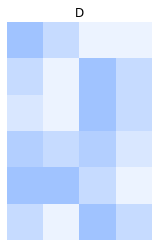

In [15]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
cm_0 = LinearSegmentedColormap.from_list("mycmap0", ["#ffffff","#a0c3ff"])
cm_1 = LinearSegmentedColormap.from_list("mycmap1", ["#ffffff", "#ffa1cf"])
cm_2 = LinearSegmentedColormap.from_list("mycmap2", ["#ffffff", "#f37726"])

plt.imshow(D,vmin = 0, vmax = 5, cmap=cm_0)
plt.title("D")
plt.axis('off')
plt.show()

We compute the SVD of the matrix $D$:

In [7]:
U, s, Vᵀ = np.linalg.svd(D,full_matrices=True)

We get a rank-2 approximation of $D$ by truncating the SVD to two singular values and vectors: 
$$D\approx U_{\cdot \{1,2\}}\Sigma_{\{1,2\}\{1,2\}}V_{\cdot \{1,2\}}^\top.$$ 
The tri-factorization of SVD can be expressed as a factorization into two matrices by making an arbitrary split into the product of two matrices. For example, we could set $Y=U_{\cdot \{1,2\}}\Sigma_{\{1,2\}\{1,2\}}^{1/2}$ and $X=V_{\cdot \{1,2\}}\Sigma_{\{1,2\}\{1,2\}}^{1/2}$. This way, we can expect that $Y$ and $X$ are similarly scaled, since they both are matrices with unitary vectors that are scaled by the square roots of the singular values. However, in principle, any split of the SVD product into two matrices will do. 
```{note}
The matrix $A^{1/2}$ is defined as the matrix that satisfies the equation $A^{1/2}A^{1/2}=A$. Not for all matrices $A$ exists such a matrix $A^{1/2}$. However, for nonnegative, diagonal matrices $\Sigma$, the matrix $\Sigma^{1/2}=\diag(\sqrt{\sigma_1},\ldots, \sqrt{\sigma_r})$ exists.
```

In [16]:
np.set_printoptions(precision=2,suppress=True)
Y = U[:,0:2]*np.sqrt(s[0:2])
X = Vᵀ.T[:,0:2]*np.sqrt(s[0:2])
Y,X

(array([[-1.3 ,  1.26],
        [-1.61, -0.85],
        [-1.46, -1.04],
        [-1.71,  0.21],
        [-1.81,  1.27],
        [-1.61, -0.85]]),
 array([[-2.3 ,  1.08],
        [-1.49,  1.38],
        [-2.43, -1.36],
        [-1.35, -0.92]]))

The low rank approximation can be used to give recommendations.

In [10]:
Y@X.T

array([[4.34, 3.68, 1.43, 0.59],
       [2.78, 1.23, 5.08, 2.97],
       [2.23, 0.75, 4.97, 2.93],
       [4.16, 2.84, 3.88, 2.13],
       [5.53, 4.46, 2.68, 1.28],
       [2.78, 1.23, 5.08, 2.97]])

If we compare the matrix above with the matrix having missing values, then we see that the low rank approximation gives some tendencies for recommendations, but often no very clear recommendation indications. This is not very surprising, since we had just a small dataset and comparatively many missing values. The rank-2 approximation is already a bit too well adapting to the missing values neutral rating.

\begin{align}
  \begin{pmatrix}
    5 & \mu & 1 & 1 \\
    \mu & 1 & 5 & \mu  \\\
    2 & 1 & 5 & 3 \\
    4 & \mu & 4 & 2\\
    5 & 5 & \mu & 1 \\
    \mu & 1 & 5 & 3 \\
  \end{pmatrix}
  &\approx
  \begin{pmatrix}
    4.3 & 3.7 & 1.4 & 0.6\\
    2.8 & 1.2 & 5.1 & 3.0\\
    2.2 & 0.7 & 5.0 & 2.9\\
    4.2 & 2.8 & 3.9 & 2.1\\
    5.5 & 4.5 & 2.7 & 1.3\\
    2.8 & 1.2 & 5.1 & 3.0
  \end{pmatrix}
\end{align}

If we plot the original data and the approximation next to another, then we also see that there are no big differences. 

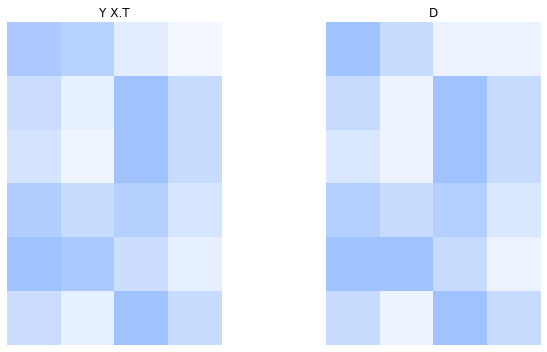

In [19]:
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
cm_0 = LinearSegmentedColormap.from_list("mycmap0", ["#ffffff","#a0c3ff"])
cm_1 = LinearSegmentedColormap.from_list("mycmap1", ["#ffffff", "#ffa1cf"])
cm_2 = LinearSegmentedColormap.from_list("mycmap2", ["#ffffff", "#f37726"])

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot first matrix
axes[0].imshow(Y@X.T, vmin=0, vmax=5, cmap=cm_0)
axes[0].set_title("Y X.T")
axes[0].axis('off')

# Plot second matrix
axes[1].imshow(D, vmin=0, vmax=5, cmap=cm_0)
axes[1].set_title("D")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Interpretation of the Factorization
The rank-two matrix product is composed by the sum of two outer products. Every outer product indicates the interaction of a user-pattern with a movie pattern. Hence, looking at the outer-product decomposition is useful for interpretation purposes. The equation below shows again the rank-two approximation. 

\begin{align*}
  \begin{pmatrix}
    5 & \mu & 1 & 1 \\
    \mu & 1 & 5 & \mu  \\\
    2 & 1 & 5 & 3 \\
    4 & \mu & 4 & 2\\
    5 & 5 & \mu & 1 \\
    \mu & 1 & 5 & 3 \\
  \end{pmatrix}
  &\approx
  \begin{pmatrix}
    -0.3 & 0.5\\
    -0.4 & -0.4\\
    -0.4 & -0.4\\
    -0.4 & 0.1\\
    -0.5 & 0.5\\
    -0.4 & -0.4\\
  \end{pmatrix}
  \begin{pmatrix}
    -9.0 & -5.8 & -9.5 & -5.3\\
    2.6 & 3.3 & -3.3 & -2.2\\
  \end{pmatrix}
\end{align*}
Every user's preferences are approximated by a linear combination of the rows in the second matrix. The rows in the second matrix have an interpretation as movie patterns. For example, the first user adheres to the first movie pattern with a factor of $-0.3$ and to the second movie pattern with a factor of $0.5$.
\begin{align*}
    \begin{pmatrix}
        5 & \mu & 1 & 1 
    \end{pmatrix}
    \approx&
    -0.3\cdot 
    \begin{pmatrix}
        -9.0 & -5.8 & -9.5 & -5.3
    \end{pmatrix}
    +0.5\cdot
    \begin{pmatrix}
        2.6 & 3.3 & -3.3 & -2.2
    \end{pmatrix}    
\end{align*}
We visualize the sum of the two outer products with colored matrices. The more saturated the color, the  higher is the absolute value of the corresponding element in the matrix. Positive values are blue and negative values are pink.  

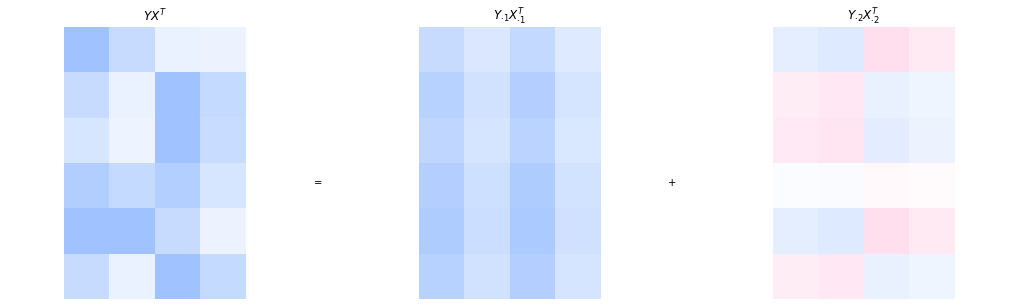

In [38]:
plt.figure(2, figsize=(18, 5))
cm_bm = LinearSegmentedColormap.from_list("mycmapbm", ["#ffa1cf","#ffffff","#a0c3ff"])
#--------------
plt.subplot(1,3,1)
plt.imshow(Y@X.T,vmin = -5, vmax = 5,cmap=cm_bm)
plt.title("$YX^T$")
plt.axis('equal')
plt.axis('off')
plt.text(5,3, '=')

plt.subplot(1,3,2)
plt.imshow(np.outer(Y[:,0],X[:,0]),vmin = -5, vmax = 5,cmap=cm_bm)
plt.title("$Y_{\cdot 1}X_{\cdot 1}^T$")
plt.axis('equal')
plt.axis('off')
plt.text(5,3, '+')

plt.subplot(1,3,3)
plt.imshow(np.outer(Y[:,1],X[:,1]),vmin = -5, vmax = 5,cmap=cm_bm)
plt.title("$Y_{\cdot 2}X_{\cdot 2}^T$")
plt.axis('equal') 
plt.axis('off')
plt.show()

The visualization makes the grid structure induced by the outer product apparent. The first movie pattern is
$\begin{pmatrix}
-9.0 & -5.8 & -9.5 & -5.3
\end{pmatrix}.$
However, since all entries of the corresponding user pattern are negative as well, it is more intuitive to flip the signs and consider the equivalent movie pattern
$\begin{pmatrix}
9 & 5.8 & 9.5 & 5.3
\end{pmatrix}.$
This sign change does not affect the resulting outer product. It merely changes the interpretation: positive coefficients are easier to interpret, since they directly indicate how strongly a user adheres to the corresponding latent pattern.
The pattern represented by the first outer product $Y_{\cdot 1}X_{\cdot 1}^{\top}$ is visible in the higher intensity of the first and third columns, reflecting the large values $9$ and $9.5$ in the movie pattern. Roughly speaking, this outer product captures a preference for movies 1 and 3 relative to the other movies.

However, we cannot draw conclusions from a single outer product in isolation. For example, user 2 has a comparatively large (sign-corrected) coefficient of $0.4$ for the first pattern, suggesting a strong preference for movie 1 and movie 3. Based on the first outer product alone, movie 1 would receive a score of $0.4 \cdot 9 = 3.6.$
Yet the final prediction is obtained from the sum of all outer products. In this case, the second outer product contributes $-0.4 \cdot 2.6 = -1.04,$ thereby reducing the score substantially. Indeed, movie 1 is not known to be a particular preference of user 2, it is actually a missing entry in the original matrix.

Hence, individual outer products should not be interpreted independently. Rather, they collectively form the approximation. Nevertheless, the importance of the outer products typically decreases with their index, since the singular values decrease in magnitude. Visually, this can be seen in the fading colors of the second outer product, whose contribution is noticeably weaker than that of the first.
  

### What Happens When We Increase the Rank?
The rank of the matrix factorization is a hyperparameter. If we choose the rank too low, then the approximation might underfit and some of the patterns in the data remain undiscovered. If the rank is too high, then the model also approximates noise-effects from the data and overfits. Noise effects could be in the recommender setting fluctuations in the mood of the user at the time of the rating. In the setting of the matrix completion task, a too high rank also results in an approximation of the neutral rankings that are imputed for the missing values. 

We visualize the factorization with a rank of three below. We see that the third outer product does make some minor corrections for user 1 and 5. At this point, the information in the third outer product becomes neglectable and should not be included in the model.

In [32]:
X = Vᵀ.T[:,0:3]*np.sqrt(s[0:3])
Y = U[:,0:3]*np.sqrt(s[0:3])

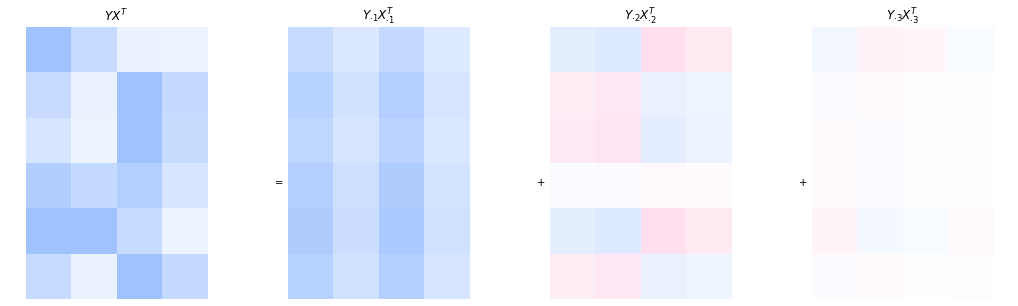

In [37]:
plt.figure(2, figsize=(18, 5))
#--------------
plt.subplot(1,4,1)
plt.imshow(Y@X.T,vmin = -5, vmax = 5,cmap=cm_bm)
plt.title("$YX^T$")
plt.axis('equal')
plt.axis('off')
plt.text(5,3, '=')

plt.subplot(1,4,2)
plt.imshow(np.outer(Y[:,0],X[:,0]),vmin = -5, vmax = 5,cmap=cm_bm)
plt.title("$Y_{\cdot 1}X_{\cdot 1}^T$")
plt.axis('equal')
plt.axis('off')
plt.text(5,3, '+')

plt.subplot(1,4,3)
plt.imshow(np.outer(Y[:,1],X[:,1]),vmin = -5, vmax = 5,cmap=cm_bm)
plt.title("$Y_{\cdot 2}X_{\cdot 2}^T$")
plt.axis('equal')
plt.axis('off')
plt.text(5,3, '+')

plt.subplot(1,4,4)
plt.imshow(np.outer(Y[:,2],X[:,2]),vmin = -5, vmax = 5,cmap=cm_bm)
plt.title("$Y_{\cdot 3}X_{\cdot 3}^T$")
plt.axis('equal')
plt.axis('off')
plt.show()

## A More Advanced Recommender System
The SVD of the rating matrix with neutral rating imputations gave us some indications of possible recommendations, but an issue with this simple approach is that the imputed missing values are also approximated by the factorization. Especially when observations are sparse, which is often the case as in movie recommendations, then this method won't work because the actual ratings will be perceived as outliers.

An idea to solve the matrix completion task more accurately is to compute a factorization that approximates only the values of observed entries.
This approach has been used in the Netflix Price 2009 competition and made it to the top-3.
`````{admonition} Task (Low-Rank Matrix Factorization with Missing Values)
:class: tip
**Given** a data matrix $D\in\mathbb{R}^{n\times d}$ having observed entries $D_{ik}$ for indices $(i,k)$ where the binary indicator matrix $O\in\{0,1\}^{n\times d}$ has an entry of one $O_{ik}=1$, and a rank $r<\min\{n,d\}$.     
    
**Find** matrices $X\in\mathbb{R}^{d\times r}$ and $Y\in\mathbb{R}^{n\times r}$ whose product approximates the data matrix only on observed entries:
\begin{align}
    \min_{X,Y}&\lVert O\circ(D- YX^\top)\rVert^2 +\lambda\lVert X\rVert^2+\lambda\lVert Y\rVert^2\\ 
    &=\sum_{(i,k):O_{ik}=1}(D_{ik}-Y_{i\cdot}X_{k\cdot}^\top)^2+\lambda\lVert X\rVert^2+\lambda\lVert Y\rVert^2\\ 
    \text{s.t. }& X\in \mathbb{R}^{d\times r}, Y\in\mathbb{R}^{n\times r}
\end{align}
**Return** the low-dimensional approximation of the data $(X,Y)$.  
`````
### Optimization
The low-rank MF on observed entries can not be computed directly by SVD. However, we can derive the minimizers of one column of $X$ and $Y$ when fixing the other matrix.
```{prf:theorem}
The minimizers of the objective to minimize $\lVert O\circ(D- YX^\top)\rVert^2$ subject to a row of $X$ or $Y$ is given as:
\begin{align*}
&D_{\cdot k}^\top \diag(O_{\cdot k})Y(Y^\top \diag(O_{\cdot k}) Y+\lambda I)^{-1}\\ 
&\quad = \argmin_{X_{k\cdot}}
\lVert O\circ(D- YX^\top)\rVert^2 + \lambda\lVert X\rVert^2\\
&D_{i\cdot} \diag(O_{i\cdot})X(X^\top \diag(O_{i\cdot}) X+\lambda I)^{-1}\\ 
&\quad = \argmin_{Y_{i\cdot}}
\lVert O\circ(D- YX^\top)\rVert^2 + \lambda\lVert Y\rVert^2
\end{align*}

```
````{toggle}
```{prf:proof}
We show the result for minimizing over $X_{k\cdot}$, the result for $Y_{i\cdot}$ follows by transposing the factorization. First, we observe that the minimization subject to $X_{k\cdot}$ reduces to the minimization over the $k$-th column:
\begin{align*}
\argmin_{X_{k\cdot}}&
\lVert O\circ(D- YX^\top)\rVert^2 + \lambda\lVert X\rVert^2\\
&= \argmin_{X_{k\cdot}}
\lVert O_{\cdot k}\circ(D_{\cdot k}- YX_{k\cdot }^\top)\rVert^2+ \lambda\lVert X_{k\cdot}\rVert^2
\end{align*}
The element-wise multiplication with the binary vector $O_{\cdot k}$ selects the rows for which we have observed entries in column $k$. This selection of rows can also be performed with a multiplication of $\diag(O_{\cdot k})$ from the left. This way, we can write the objective to optimize subject to $X_{k\cdot}$ as
\begin{align*}
\argmin_{X_{k\cdot}}&
\lVert O\circ(D- YX^\top)\rVert^2 + \lambda\lVert X\rVert^2\\ 
&= \argmin_{X_{k\cdot}}
\lVert \underbrace{\diag(O_{\cdot k})D_{\cdot k}}_{=\tilde{\vvec{y}}}- \underbrace{\diag(O_{\cdot k})Y}_{=\tilde{X}}\underbrace{X_{k\cdot }^\top}_{=\tilde{\beta}})\rVert^2 + \lambda\lVert X\rVert^2 
\end{align*}
The objective above is equivalent to a ridge regression objective (using the notation of ridge regression, the target vector $\tilde{\vvec{y}}$, the design matrix $\tilde{X}$ and the parameter vector $\tilde{\beta}$ are annotated above). We know the minimizer of this objective, it is given by the vector
\begin{align*}
(\tilde{X}^\top \tilde{X}+\lambda I)^{-1}\tilde{X}^\top\tilde{\vvec{y}}
&= (Y^\top \diag(O_{\cdot k})^2 Y +\lambda I)^{-1} Y^\top\diag(O_{\cdot k})^2D_{\cdot k}\\
&=(Y^\top \diag(O_{\cdot k}) Y +\lambda I)^{-1} Y^\top\diag(O_{\cdot k})D_{\cdot k}
\end{align*}
where the last equation follows from the fact that binary values do not change when they are squared.
```
````
The theorem above motivates a block-coordinate descent approach, where we go in every iteration through each column of $X$ and $Y$ and update it. This procedure is described in the algorithm below.
```{prf:algorithm} MatrixCompletion

**Input**: the dataset $D$, rank $r$, maximum number of iterations $t_{max} = 100$, and regularization weight  $\lambda = 0.1$
1. $(X, Y) \gets$ `InitRandom`$(n, d, r)$ 
2. $O \gets$ `IndicatorObserved`$(D)$
2. **for** $t\in\{1,\ldots,t_{max}\}$
    1. **for** $k \in \{1, \ldots, d\}$
        1. $X_{k\cdot} \leftarrow D_{\cdot k}^{\top} \diag(O_{\cdot k})Y (Y^{\top} \diag(O_{\cdot k}) Y + \lambda I)^{-1}$
    2. **for** $i \in \{1, \ldots, n\}$
        1. $Y_{i\cdot} \leftarrow D_{i\cdot}\diag(O_{i\cdot}) X (X^{\top} \diag(O_{i\cdot}) X + \lambda I)^{-1}$
3. **return** $(X,Y)$
```

## From Unsupervised Matrix Completion to Supervised Behavioral Modeling

Early recommender systems, such as those based on matrix factorization, are traditionally framed as unsupervised learning problems. The central task is to complete a sparse user-item rating matrix by learning latent factors that explain the observed ratings. This process resembled dimensionality reduction (e.g., via SVD), and the goal was to estimate the missing entries as accurately as possible.

However, this perspective has shifted in modern systems.
Today, most recommendation systems rely not on explicit ratings, but on **implicit feedback**:

- Clicks, taps, swipes
- Watch time or scroll depth
- Song plays, skips, replays
- Add-to-cart or wishlist events

These behaviors are logged at scale, and treated as training signals for supervised learning. The recommendation problem becomes "_Given past behavior, predict whether a user will interact with an item._"

This makes modern recommendation fundamentally a prediction task, rather than a pure matrix completion task. Reformulating the unsupervised recommender system task into a supervised one has the advantages that we can test the performance and tune hyperparameters to maximize performance. In addition, it provides control over the purpose of the prediction, such as keeping users hooked to the screen, which is generally easier to monetize than solving the more general task of providing good recommendations.